# Artifact Rejection on Real EEG Data
## BrainBit & CalmSync Devices
---

In the previous notebook we explored artifact rejection techniques (WT, EMD, CEEMDAN) on **synthetic** signals where we knew the ground truth. Now we apply these same ideas to **real EEG recordings** from two consumer-grade devices:

| Device | Channels | Sampling Rate | Format |
|--------|----------|---------------|--------|
| **BrainBit** | 8 (Fz, F3, Cz, F4, Pz, Fp1, Fp2, Oz) | ~250 Hz | XDF |
| **CalmSync** | 2 (Fp1, Fp2) | ~240 Hz | JSON |

We focus on the **Fp1** channel from each device — the frontal electrode most sensitive to eye blink artifacts. We take the **first 30 seconds**, preprocess with a basic bandpass + notch filter, and then decompose using **EMD** to visualise the Intrinsic Mode Functions (IMFs).

## 1. Load & Preprocess
---
We load both devices, scale to **µV**, and apply a minimal preprocessing pipeline:
- **Bandpass filter:** 0.1 – 45 Hz (removes DC drift and high-frequency noise)
- **Notch filter:** 50 Hz (removes line noise)
- **DC removal:** subtract the mean

In [ ]:
import numpy as np
import json
import matplotlib.pyplot as plt
import pyxdf
from scipy import signal
from PyEMD import EMD
from scipy.signal import welch

# ── Filter helper ────────────────────────────────────────────────────────────
def preprocess(x, fs, hp=0.1, lp=45.0, notch=50.0):
    """Bandpass 0.1-45 Hz + 50 Hz notch filter, then DC removal."""
    sos_bp = signal.butter(4, [hp, lp], btype='band', fs=fs, output='sos')
    x = signal.sosfiltfilt(sos_bp, x)
    b, a = signal.iirnotch(notch, Q=30, fs=fs)
    x = signal.filtfilt(b, a, x)
    x -= x.mean()
    return x

# ═══════════════════════════════════════════════════════════════════════════════
# LOAD BRAINBIT (XDF)
# ═══════════════════════════════════════════════════════════════════════════════
xdf_path = r"../Data/Brainbit/Archi_27febgoodbadimages.xdf"
streams, _ = pyxdf.load_xdf(xdf_path)

eeg_stream = None
for s in streams:
    if s['info']['type'][0].lower() == 'eeg' and len(s['time_stamps']) > 0:
        eeg_stream = s
        break

raw_data = np.array(eeg_stream['time_series']).T
eeg_ts = np.array(eeg_stream['time_stamps'])
bb_fs = float(1.0 / np.median(np.diff(eeg_ts - eeg_ts[0])))

BB_CHAN_NAMES = ['Fz', 'F3', 'Cz', 'F4', 'Pz', 'Fp1', 'Fp2', 'Oz']
fp1_idx = BB_CHAN_NAMES.index('Fp1')

bb_fp1 = raw_data[fp1_idx, :].astype(float)

# Unit scaling
max_abs = np.max(np.abs(raw_data))
if max_abs < 1.0:
    bb_fp1 *= 1e6
    print(f"BrainBit units: Volts (max={max_abs:.4f}) \u2192 scaled to \u00b5V")
elif max_abs <= 1000:
    bb_fp1 *= 1e3
    print(f"BrainBit units: mV (max={max_abs:.2f}) \u2192 scaled to \u00b5V")
else:
    print(f"BrainBit units: already \u00b5V (max={max_abs:.1f})")

bb_fp1 = preprocess(bb_fp1, bb_fs)

# ═══════════════════════════════════════════════════════════════════════════════
# LOAD CALMSYNC (JSON)
# ═══════════════════════════════════════════════════════════════════════════════
json_path = r"../Data/Calmsync/eeg_2026-02-27T16-33-22_2026-02-27T16-36-16.json"
with open(json_path) as f:
    cs_json = json.load(f)

cs_fs = cs_json['samplingRateHz']
cs_raw = np.array(cs_json['data'], dtype=float)

# ADC \u2192 \u00b5V conversion
cs_fp1 = ((cs_raw[0] - 512) * 3.3 / 1024) / 1100 * 1e6
cs_fp1 = preprocess(cs_fp1, cs_fs)

# ═══════════════════════════════════════════════════════════════════════════════
# EXTRACT FIRST 30 SECONDS
# ═══════════════════════════════════════════════════════════════════════════════
duration = 30  # seconds

bb_n = int(duration * bb_fs)
bb_seg = bb_fp1[:bb_n]
bb_t = np.arange(bb_n) / bb_fs

cs_n = int(duration * cs_fs)
cs_seg = cs_fp1[:cs_n]
cs_t = np.arange(cs_n) / cs_fs

print(f"\nBrainBit Fp1: {bb_n} samples, fs={bb_fs:.1f} Hz, duration={duration}s")
print(f"CalmSync Fp1: {cs_n} samples, fs={cs_fs} Hz, duration={duration}s")

## 2. Raw EEG — First 30 Seconds
---
Let's first look at the raw filtered signal from both devices. Eye blink artifacts appear as large, sharp deflections — especially prominent on the **Fp1** frontal channel.

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(bb_t, bb_seg, color='steelblue', linewidth=0.5)
axes[0].set_title('BrainBit — Fp1 (first 30s)', fontsize=12)
axes[0].set_ylabel('Amplitude (\u00b5V)')

axes[1].plot(cs_t, cs_seg, color='teal', linewidth=0.5)
axes[1].set_title('CalmSync — Fp1 (first 30s)', fontsize=12)
axes[1].set_ylabel('Amplitude (\u00b5V)')
axes[1].set_xlabel('Time (s)')

for ax in axes:
    ax.grid(alpha=0.3)

fig.suptitle('Raw Filtered EEG — Fp1 Channel', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3. EMD Decomposition — BrainBit
---
We apply **Empirical Mode Decomposition** to the BrainBit Fp1 signal. Each resulting **IMF** captures a different oscillatory mode — from the highest frequencies (IMF 1) down to the slowest trend (residual). Blink artifacts typically concentrate in the **first few IMFs** (high energy, low entropy, high kurtosis).

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# EMD — BrainBit Fp1
# ═══════════════════════════════════════════════════════════════════════════════
emd_bb = EMD()
imfs_bb = emd_bb.emd(bb_seg, bb_t)
n_imfs_bb = imfs_bb.shape[0]

print(f"BrainBit EMD: {n_imfs_bb} IMFs extracted")

# --- Plot IMFs ---
fig, axes = plt.subplots(n_imfs_bb + 1, 1,
                          figsize=(14, 2.0 * (n_imfs_bb + 1)), sharex=True)

# Original signal on top
axes[0].plot(bb_t, bb_seg, color='steelblue', linewidth=0.6)
axes[0].set_title('Original Signal (BrainBit Fp1)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('\u00b5V')

# Compute PSD dominant frequency for each IMF
for i in range(n_imfs_bb):
    f, psd = welch(imfs_bb[i], fs=bb_fs, nperseg=min(256, len(imfs_bb[i])))
    dom_freq = f[np.argmax(psd)]
    energy_pct = np.sum(imfs_bb[i]**2) / np.sum(bb_seg**2) * 100

    color = '#e74c3c' if i >= n_imfs_bb - 2 else 'teal'  # last 2 = slow trend
    axes[i+1].plot(bb_t, imfs_bb[i], color=color, linewidth=0.5)
    axes[i+1].set_title(
        f'IMF {i+1}  |  Dominant freq: {dom_freq:.1f} Hz  |  '
        f'Energy: {energy_pct:.1f}%',
        fontsize=9)
    axes[i+1].set_ylabel('\u00b5V', fontsize=8)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('EMD Decomposition — BrainBit Fp1 (first 30s)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. EMD Decomposition — CalmSync
---
Same decomposition on the **CalmSync** Fp1 channel. Since CalmSync is a 2-channel consumer device with a different amplifier, the noise characteristics and artifact shapes may differ.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# EMD — CalmSync Fp1
# ═══════════════════════════════════════════════════════════════════════════════
emd_cs = EMD()
imfs_cs = emd_cs.emd(cs_seg, cs_t)
n_imfs_cs = imfs_cs.shape[0]

print(f"CalmSync EMD: {n_imfs_cs} IMFs extracted")

# --- Plot IMFs ---
fig, axes = plt.subplots(n_imfs_cs + 1, 1,
                          figsize=(14, 2.0 * (n_imfs_cs + 1)), sharex=True)

axes[0].plot(cs_t, cs_seg, color='teal', linewidth=0.6)
axes[0].set_title('Original Signal (CalmSync Fp1)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('\u00b5V')

for i in range(n_imfs_cs):
    f, psd = welch(imfs_cs[i], fs=cs_fs, nperseg=min(512, len(imfs_cs[i])))
    dom_freq = f[np.argmax(psd)]
    energy_pct = np.sum(imfs_cs[i]**2) / np.sum(cs_seg**2) * 100

    color = '#e74c3c' if i >= n_imfs_cs - 2 else 'darkorange'
    axes[i+1].plot(cs_t, imfs_cs[i], color=color, linewidth=0.5)
    axes[i+1].set_title(
        f'IMF {i+1}  |  Dominant freq: {dom_freq:.1f} Hz  |  '
        f'Energy: {energy_pct:.1f}%',
        fontsize=9)
    axes[i+1].set_ylabel('\u00b5V', fontsize=8)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('EMD Decomposition — CalmSync Fp1 (first 30s)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. Hilbert Transform on IMFs — Visualising Mode Mixing
---
The **Hilbert Transform** converts each IMF into an **analytic signal**, from which we extract the **instantaneous frequency** at every time point. 

If EMD worked perfectly, each IMF would sit at a **single, distinct frequency band** — you'd see flat, well-separated horizontal lines. In practice, we see **mode mixing**: frequencies jumping within a single IMF, or the same frequency appearing in multiple IMFs. This is a fundamental limitation of vanilla EMD.

For each device we show two panels side by side:
- **Left:** All IMFs stacked (time domain)
- **Right:** Instantaneous frequency of each IMF superimposed on one plot (Hilbert–Huang spectrum)

BrainBit Fp1


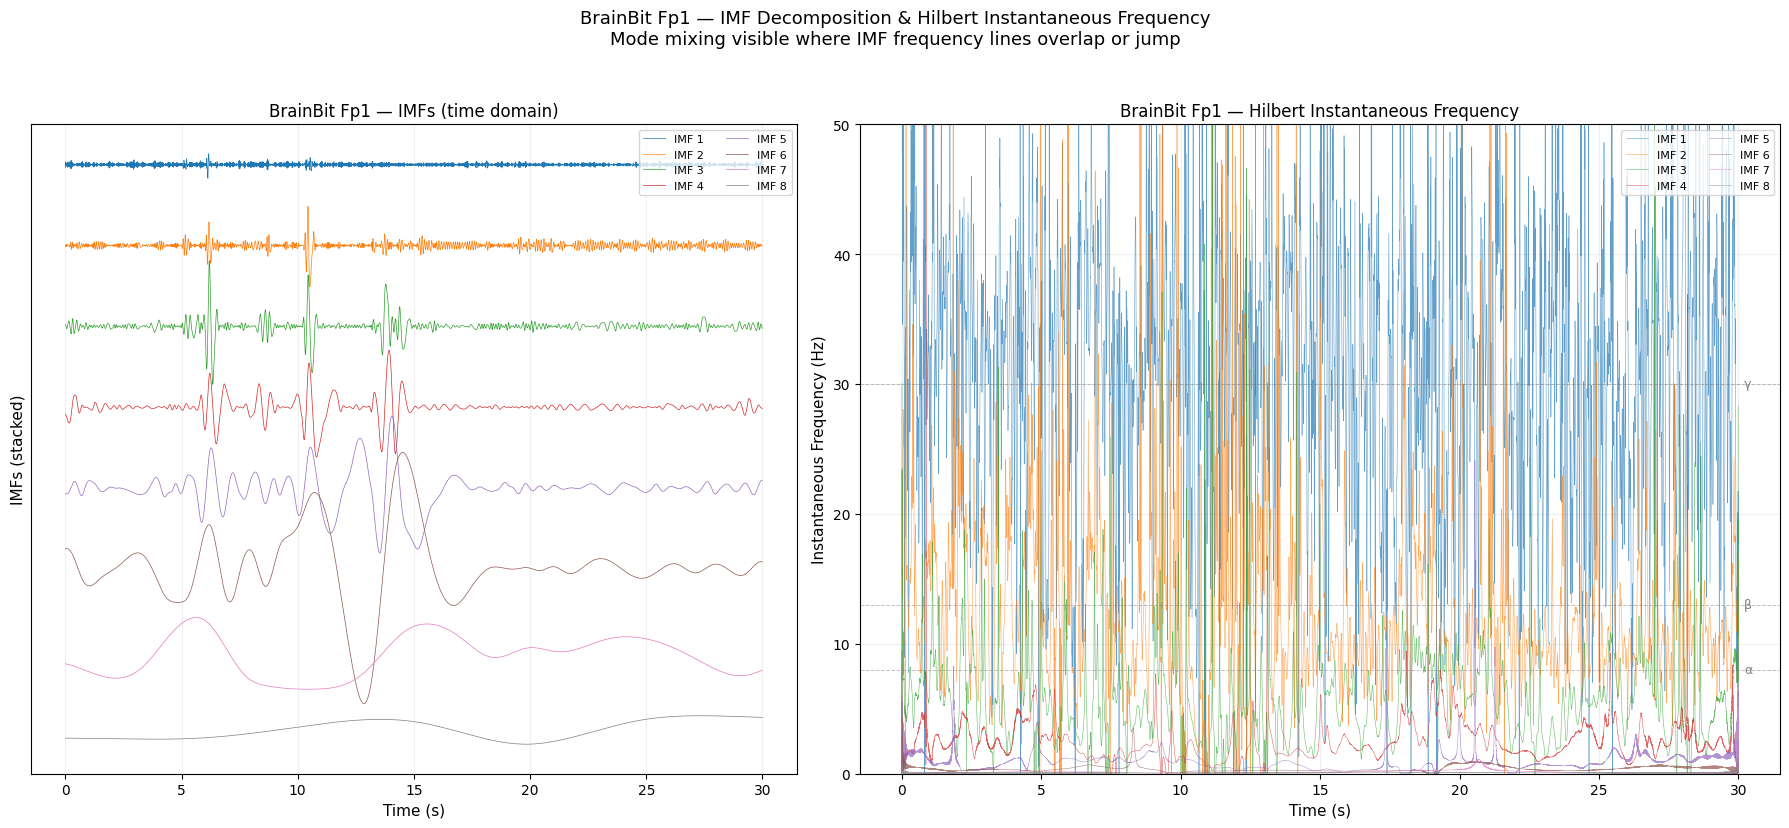


CalmSync Fp1


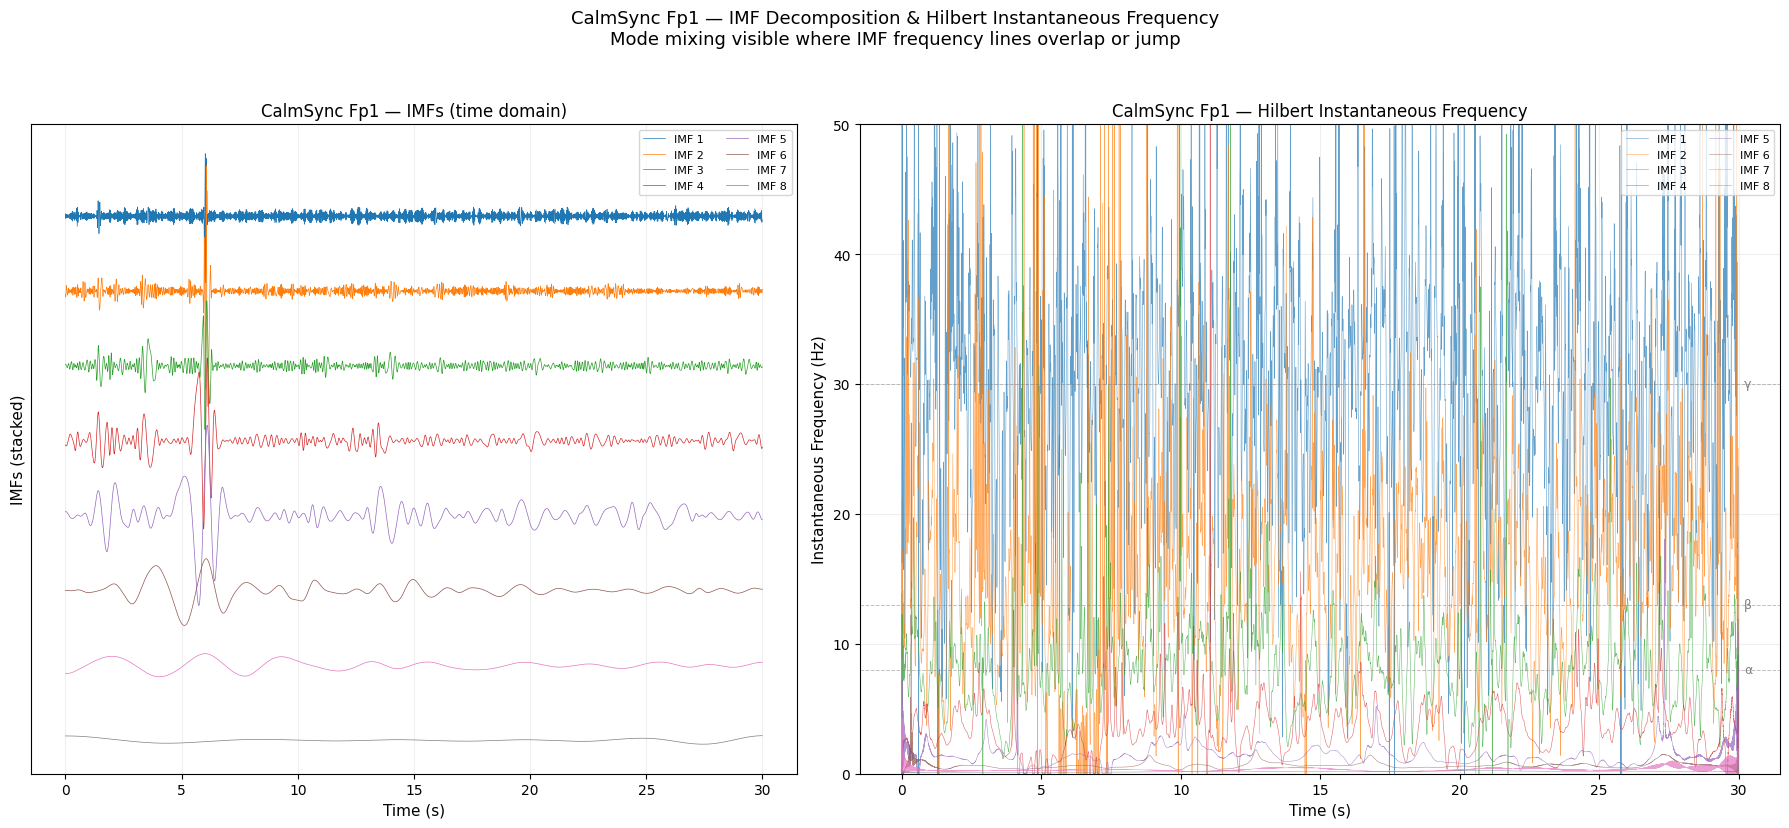

In [7]:
from scipy.signal import hilbert

# ── Hilbert instantaneous frequency helper ──────────────────────────────────
def instantaneous_frequency(imf, fs):
    """Compute instantaneous frequency from Hilbert transform of an IMF."""
    analytic = hilbert(imf)
    phase = np.unwrap(np.angle(analytic))
    inst_freq = np.diff(phase) / (2.0 * np.pi) * fs
    return inst_freq

# ── Color palette for IMFs ──────────────────────────────────────────────────
cmap = plt.cm.tab10

def plot_imfs_and_hilbert(imfs, t, fs, device_name, sig_color):
    """Two-panel figure: Left = stacked IMFs, Right = Hilbert inst. freq."""
    n_imfs = imfs.shape[0]
    # Skip the last IMF (residual/trend) for Hilbert — it's not oscillatory
    n_plot = min(n_imfs - 1, 8)

    fig, (ax_imf, ax_hht) = plt.subplots(1, 2, figsize=(18, 8),
                                          gridspec_kw={'width_ratios': [1, 1.2]})

    # ── Left panel: stacked IMFs ────────────────────────────────────────────
    offsets = []
    spacing = 0
    for i in range(n_plot):
        offset = -i * np.max(np.abs(imfs[:n_plot])) * 0.6
        offsets.append(offset)
        ax_imf.plot(t, imfs[i] + offset, color=cmap(i), linewidth=0.5,
                    label=f'IMF {i+1}')

    ax_imf.set_xlabel('Time (s)', fontsize=11)
    ax_imf.set_ylabel('IMFs (stacked)', fontsize=11)
    ax_imf.set_title(f'{device_name} — IMFs (time domain)', fontsize=12)
    ax_imf.legend(fontsize=8, loc='upper right', ncol=2)
    ax_imf.set_yticks([])
    ax_imf.grid(alpha=0.2)

    # ── Right panel: Hilbert instantaneous frequencies ──────────────────────
    for i in range(n_plot):
        inst_freq = instantaneous_frequency(imfs[i], fs)
        # Clip to reasonable EEG range for display
        inst_freq = np.clip(inst_freq, 0, fs / 2)
        ax_hht.plot(t[:-1], inst_freq, color=cmap(i), linewidth=0.4,
                    alpha=0.7, label=f'IMF {i+1}')

    ax_hht.set_xlabel('Time (s)', fontsize=11)
    ax_hht.set_ylabel('Instantaneous Frequency (Hz)', fontsize=11)
    ax_hht.set_title(f'{device_name} — Hilbert Instantaneous Frequency', fontsize=12)
    ax_hht.set_ylim(0, 50)
    ax_hht.axhline(8, color='gray', ls='--', lw=0.7, alpha=0.5)
    ax_hht.axhline(13, color='gray', ls='--', lw=0.7, alpha=0.5)
    ax_hht.axhline(30, color='gray', ls='--', lw=0.7, alpha=0.5)
    ax_hht.text(t[-1] + 0.2, 8, 'α', fontsize=9, color='gray', va='center')
    ax_hht.text(t[-1] + 0.2, 13, 'β', fontsize=9, color='gray', va='center')
    ax_hht.text(t[-1] + 0.2, 30, 'γ', fontsize=9, color='gray', va='center')
    ax_hht.legend(fontsize=8, loc='upper right', ncol=2)
    ax_hht.grid(alpha=0.2)

    fig.suptitle(
        f'{device_name} — IMF Decomposition & Hilbert Instantaneous Frequency\n'
        f'Mode mixing visible where IMF frequency lines overlap or jump',
        fontsize=13, y=1.03)
    plt.tight_layout()
    plt.show()

# ── BrainBit ────────────────────────────────────────────────────────────────
print("BrainBit Fp1")
plot_imfs_and_hilbert(imfs_bb, bb_t, bb_fs, "BrainBit Fp1", "steelblue")

# ── CalmSync ────────────────────────────────────────────────────────────────
print("\nCalmSync Fp1")
plot_imfs_and_hilbert(imfs_cs, cs_t, cs_fs, "CalmSync Fp1", "teal")

## 8. EEMD Decomposition
---
**Ensemble EMD** adds white noise to the signal multiple times, runs EMD on each noisy realisation, and averages the resulting IMFs. This helps reduce **mode mixing** — we should see cleaner frequency separation in the Hilbert plot compared to vanilla EMD above.

In [ ]:
from PyEMD import EEMD

# ═══════════════════════════════════════════════════════════════════════════════
# EEMD — BrainBit Fp1
# ═══════════════════════════════════════════════════════════════════════════════
eemd = EEMD(trials=50, noise_width=0.1)
eemd_imfs_bb = eemd.eemd(bb_seg, bb_t)
n_eemd_bb = eemd_imfs_bb.shape[0]
print(f"BrainBit EEMD: {n_eemd_bb} IMFs extracted")

# --- Plot IMFs ---
fig, axes = plt.subplots(n_eemd_bb + 1, 1,
                          figsize=(14, 2.0 * (n_eemd_bb + 1)), sharex=True)

axes[0].plot(bb_t, bb_seg, color='steelblue', linewidth=0.6)
axes[0].set_title('Original Signal (BrainBit Fp1)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('\u00b5V')

for i in range(n_eemd_bb):
    f, psd = welch(eemd_imfs_bb[i], fs=bb_fs, nperseg=min(256, len(eemd_imfs_bb[i])))
    dom_freq = f[np.argmax(psd)]
    energy_pct = np.sum(eemd_imfs_bb[i]**2) / np.sum(bb_seg**2) * 100
    axes[i+1].plot(bb_t, eemd_imfs_bb[i], color=cmap(i % 10), linewidth=0.5)
    axes[i+1].set_title(
        f'IMF {i+1}  |  Dominant freq: {dom_freq:.1f} Hz  |  Energy: {energy_pct:.1f}%',
        fontsize=9)
    axes[i+1].set_ylabel('\u00b5V', fontsize=8)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('EEMD Decomposition — BrainBit Fp1 (first 30s)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# --- Hilbert ---
print("\nBrainBit EEMD — Hilbert")
plot_imfs_and_hilbert(eemd_imfs_bb, bb_t, bb_fs, "BrainBit EEMD", "steelblue")

# ═══════════════════════════════════════════════════════════════════════════════
# EEMD — CalmSync Fp1
# ═══════════════════════════════════════════════════════════════════════════════
eemd_imfs_cs = eemd.eemd(cs_seg, cs_t)
n_eemd_cs = eemd_imfs_cs.shape[0]
print(f"\nCalmSync EEMD: {n_eemd_cs} IMFs extracted")

fig, axes = plt.subplots(n_eemd_cs + 1, 1,
                          figsize=(14, 2.0 * (n_eemd_cs + 1)), sharex=True)

axes[0].plot(cs_t, cs_seg, color='teal', linewidth=0.6)
axes[0].set_title('Original Signal (CalmSync Fp1)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('\u00b5V')

for i in range(n_eemd_cs):
    f, psd = welch(eemd_imfs_cs[i], fs=cs_fs, nperseg=min(512, len(eemd_imfs_cs[i])))
    dom_freq = f[np.argmax(psd)]
    energy_pct = np.sum(eemd_imfs_cs[i]**2) / np.sum(cs_seg**2) * 100
    axes[i+1].plot(cs_t, eemd_imfs_cs[i], color=cmap(i % 10), linewidth=0.5)
    axes[i+1].set_title(
        f'IMF {i+1}  |  Dominant freq: {dom_freq:.1f} Hz  |  Energy: {energy_pct:.1f}%',
        fontsize=9)
    axes[i+1].set_ylabel('\u00b5V', fontsize=8)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('EEMD Decomposition — CalmSync Fp1 (first 30s)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\nCalmSync EEMD — Hilbert")
plot_imfs_and_hilbert(eemd_imfs_cs, cs_t, cs_fs, "CalmSync EEMD", "teal")

## 9. CEEMDAN Decomposition
---
**CEEMDAN** (Complete Ensemble EMD with Adaptive Noise) is the most refined variant. It uses complementary positive/negative noise pairs, producing a more complete decomposition with less residual noise. Compare the Hilbert plots here with EMD (section 7) and EEMD (section 8) — the instantaneous frequency lines should be the most stable and well-separated.

In [ ]:
from PyEMD import CEEMDAN

# ═══════════════════════════════════════════════════════════════════════════════
# CEEMDAN — BrainBit Fp1
# ═══════════════════════════════════════════════════════════════════════════════
ceemdan = CEEMDAN(trials=50, epsilon=0.1)
ceemdan_imfs_bb = ceemdan.ceemdan(bb_seg, bb_t)
n_ceemdan_bb = ceemdan_imfs_bb.shape[0]
print(f"BrainBit CEEMDAN: {n_ceemdan_bb} IMFs extracted")

# --- Plot IMFs ---
fig, axes = plt.subplots(n_ceemdan_bb + 1, 1,
                          figsize=(14, 2.0 * (n_ceemdan_bb + 1)), sharex=True)

axes[0].plot(bb_t, bb_seg, color='steelblue', linewidth=0.6)
axes[0].set_title('Original Signal (BrainBit Fp1)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('\u00b5V')

for i in range(n_ceemdan_bb):
    f, psd = welch(ceemdan_imfs_bb[i], fs=bb_fs, nperseg=min(256, len(ceemdan_imfs_bb[i])))
    dom_freq = f[np.argmax(psd)]
    energy_pct = np.sum(ceemdan_imfs_bb[i]**2) / np.sum(bb_seg**2) * 100
    axes[i+1].plot(bb_t, ceemdan_imfs_bb[i], color=cmap(i % 10), linewidth=0.5)
    axes[i+1].set_title(
        f'IMF {i+1}  |  Dominant freq: {dom_freq:.1f} Hz  |  Energy: {energy_pct:.1f}%',
        fontsize=9)
    axes[i+1].set_ylabel('\u00b5V', fontsize=8)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('CEEMDAN Decomposition — BrainBit Fp1 (first 30s)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# --- Hilbert ---
print("\nBrainBit CEEMDAN — Hilbert")
plot_imfs_and_hilbert(ceemdan_imfs_bb, bb_t, bb_fs, "BrainBit CEEMDAN", "steelblue")

# ═══════════════════════════════════════════════════════════════════════════════
# CEEMDAN — CalmSync Fp1
# ═══════════════════════════════════════════════════════════════════════════════
ceemdan_imfs_cs = ceemdan.ceemdan(cs_seg, cs_t)
n_ceemdan_cs = ceemdan_imfs_cs.shape[0]
print(f"\nCalmSync CEEMDAN: {n_ceemdan_cs} IMFs extracted")

fig, axes = plt.subplots(n_ceemdan_cs + 1, 1,
                          figsize=(14, 2.0 * (n_ceemdan_cs + 1)), sharex=True)

axes[0].plot(cs_t, cs_seg, color='teal', linewidth=0.6)
axes[0].set_title('Original Signal (CalmSync Fp1)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('\u00b5V')

for i in range(n_ceemdan_cs):
    f, psd = welch(ceemdan_imfs_cs[i], fs=cs_fs, nperseg=min(512, len(ceemdan_imfs_cs[i])))
    dom_freq = f[np.argmax(psd)]
    energy_pct = np.sum(ceemdan_imfs_cs[i]**2) / np.sum(cs_seg**2) * 100
    axes[i+1].plot(cs_t, ceemdan_imfs_cs[i], color=cmap(i % 10), linewidth=0.5)
    axes[i+1].set_title(
        f'IMF {i+1}  |  Dominant freq: {dom_freq:.1f} Hz  |  Energy: {energy_pct:.1f}%',
        fontsize=9)
    axes[i+1].set_ylabel('\u00b5V', fontsize=8)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('CEEMDAN Decomposition — CalmSync Fp1 (first 30s)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\nCalmSync CEEMDAN — Hilbert")
plot_imfs_and_hilbert(ceemdan_imfs_cs, cs_t, cs_fs, "CalmSync CEEMDAN", "teal")

---
### References
*   [EEG Artifacts Handling in Analyzer — Brain Products](https://pressrelease.brainproducts.com/eeg-artifacts-handling-in-analyzer/)